In [14]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

df = pd.read_csv(
    "BIDS_FDM2324_Hausarbeit_DS_V0 (1).csv",
    sep=";",
    decimal=",",
    na_values=["NA", "na", ""]
)

print(df.head())
print(df.columns)

    ID Gender  Age Race   BMI Marital status  TypeDiabetes  \
0  502      F   50    1  33.2        married             2   
1  735      M   26    1  31.5        married             2   
2  420      F   50    1  27.6        married             2   
3  680      F   50    3  33.7        married             2   
4  504      M   33    3  18.0        married             2   

   Duration of diabetes (years)  SmokingYears  Amputation  ...  SERUMCRE  \
0                          25.0           0.0           0  ...       1.4   
1                          14.0           0.0           0  ...       NaN   
2                          14.0           0.0           0  ...       2.4   
3                          10.0          30.0           0  ...       1.5   
4                          22.0           0.0           0  ...       1.0   

   MICROALB  SERUMALB                                Hypoglycemic Agents  \
0       NaN     4.000                                      Gansulin 40R    
1       NaN     3.

In [15]:
print(df.isna().sum())

ID                                        0
Gender                                    1
Age                                       0
Race                                      0
BMI                                       0
Marital status                            5
TypeDiabetes                              0
Duration of diabetes (years)            176
SmokingYears                              0
Amputation                                0
SysBP                                     0
DiaBP                                     0
HbA1C                                     0
HDL                                      11
LDL                                       1
TRI                                      12
SERUMCRE                                 12
MICROALB                                206
SERUMALB                                101
Hypoglycemic Agents                     132
Medication Insulin                        0
Medication Sulfonylureas                  0
Medication BP                   

In [16]:
# Standardise column names
df.columns = [c.strip().lower().replace(" ", "_").replace("(", "").replace(")", "") for c in df.columns]

gender_map = {"F": "F", "M": "M", "f": "F", "m": "M"}
df["gender"] = df["gender"].astype(str).str.strip().map(gender_map)  

df["race"] = pd.to_numeric(df["race"], errors="coerce")

In [17]:
#normalise marital status
df["marital_status"] = (
    df["marital_status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"na": np.nan, "unknown": np.nan, "nan": np.nan, "": np.nan})
)

df["duration_of_diabetes_years"] = pd.to_numeric(
    df["duration_of_diabetes_years"], errors="coerce"
)

In [18]:

df["smokingyears"] = pd.to_numeric(df["smokingyears"], errors="coerce")

# Free-text field; standardise whitespace and fix typos
def clean_agents(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.lower() in ("none", "neon", "nan", ""):
        return np.nan
    
    val = re.sub(r"\s{2,}", " ", val)
    val = re.sub(r",\s*", ", ", val)
    return val

df["hypoglycemic_agents"] = df["hypoglycemic_agents"].apply(clean_agents)


In [19]:

numeric_cols = ["sysbp", "diabp", "hba1c", "hdl", "ldl", "tri",
                "serumcre", "microalb", "serumalb", "bmi"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

#make binary binary
binary_cols = ["amputation", "medication_insulin", "medication_sulfonylureas",
               "medication_bp"]
for col in binary_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# Standardise none variants, strip whitespace
for col in ["diabetic_macrovascular_complications",
            "diabetic_microvascular_complications", "comorbidities"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col] = df[col].replace({"none": np.nan, "nan": np.nan, "": np.nan})


In [20]:

# Duplicate ID check
dupes = df[df.duplicated(subset="id", keep=False)]
if not dupes.empty:
    print(f" {len(dupes)} rows share a duplicate ID — review before dropping:")
    print(dupes[["id", "gender", "age", "hba1c"]].to_string())
    
#logic checks
flags = pd.DataFrame(index=df.index)
flags["hba1c_suspicious"] = df["hba1c"].notna() & ~df["hba1c"].between(3, 20)
flags["bmi_suspicious"] = df["bmi"].notna() & ~df["bmi"].between(10, 80)
flags["sysbp_suspicious"] = df["sysbp"].notna() & ~df["sysbp"].between(60, 300)
flags["age_suspicious"] = df["age"].notna() & ~df["age"].between(0, 120)

for col in flags.columns:
    n = flags[col].sum()
    if n:
        print(f" {n} suspicious value(s) in {col}")


 24 rows share a duplicate ID — review before dropping:
      id gender  age  hba1c
22   126      F   33    5.6
30   138    NaN   48    5.8
62   102      F   35    6.4
63   126      M   51    6.4
64   134      F   30    6.4
66   138      F   57    6.4
69   143      M   63    6.4
74   150      F   40    6.5
78   161      F   60    6.6
84   182      M   60    6.6
85   186      M   77    6.7
87   197      F   57    6.7
131   12      M   55    7.7
139  146      M   30    7.8
142   12      M   31    7.9
162  102      F   54    9.0
170  150      F   42   11.7
185  134      F   63    5.8
192  143      F   48    5.9
193  146      F   48    5.9
194  161      M   57    5.9
215  182      F   59    6.2
221  186      F   54    6.3
226  197      M   69    6.4


In [21]:


df["smokingyears"] = df["smokingyears"].round().astype("Int64")
df["duration_of_diabetes_years"] = df["duration_of_diabetes_years"].round().astype("Int64")


for col in ["hypoglycemic_agents", "diabetic_macrovascular_complications",
            "diabetic_microvascular_complications", "comorbidities"]:
    if col in df.columns:
        df[col] = df[col].str.replace(", ", " | ", regex=False)
        
print(f"\nShape: {df.shape}")
print(f"Missing values per column:\n{df.isna().sum()}")




Shape: (285, 26)
Missing values per column:
id                                        0
gender                                    4
age                                       0
race                                      2
bmi                                       0
marital_status                            6
typediabetes                              0
duration_of_diabetes_years              176
smokingyears                              0
amputation                                0
sysbp                                     0
diabp                                     0
hba1c                                     0
hdl                                      11
ldl                                       1
tri                                      12
serumcre                                 12
microalb                                206
serumalb                                101
hypoglycemic_agents                     139
medication_insulin                        0
medication_sulfonylureas       

## How to handle Null values
### General

Gender -> 4 values missing, Create Unknown M/F/U

Race -> 4 values missing, Create Unknown M/F/U

duration of diabetes years -> 176 null values trash

Marital status -> 6, fill with Unknown

### Blood Fats, colesterol stuff
hdl -> 11 fill with median

ldl -> 1 fill with median

tri -> 12 fill with median

### Kidney stuff
serumcre -> 12, fill with median -> likely only kidney marker with enough values

microlabn -> 206 trash, goes in trash

serumalb -> 101 mostly trash, also goes in trash

### Diabetes specific, blood sugar lowering meds
hypogycemic_agents -> 139 goes in the trash

### Conditions 
diabetic_macrovascular_complications -> 173 much but ok because not everybody has a condition

diabetic_microvascular_complications -> 205 same as macrovascular

comorbidities -> other conditions, high null also allowed



In [22]:
df["gender"] = df["gender"].fillna("U")
df["race"] = df["race"].fillna(0)
df["race"] = df["race"].astype("Int64")
df["marital_status"] = df["marital_status"].fillna("unknown")

df["hdl"] = df["hdl"].fillna(df["hdl"].median())
df["ldl"] = df["ldl"].fillna(df["ldl"].median())
df["tri"] = df["tri"].fillna(df["tri"].median())

df["serumcre"] = df["serumcre"].fillna(df["serumcre"].median())

df.drop(columns=["duration_of_diabetes_years", "microalb", "serumalb", "hypoglycemic_agents"], inplace=True)
df.dtypes

id                                        int64
gender                                      str
age                                       int64
race                                      Int64
bmi                                     float64
marital_status                              str
typediabetes                              int64
smokingyears                              Int64
amputation                                Int64
sysbp                                     int64
diabp                                     int64
hba1c                                   float64
hdl                                     float64
ldl                                     float64
tri                                     float64
serumcre                                float64
medication_insulin                        Int64
medication_sulfonylureas                  Int64
medication_bp                             Int64
diabetic_macrovascular_complications        str
diabetic_microvascular_complications    

In [23]:
df.to_csv("cleaned_data.csv", index=False, decimal=".")
print("\nSaved to cleaned_data.csv")


Saved to cleaned_data.csv


In [24]:
print(f"\nShape: {df.shape}")
print(f"Missing values per column:\n{df.isna().sum()}")


Shape: (285, 22)
Missing values per column:
id                                        0
gender                                    0
age                                       0
race                                      0
bmi                                       0
marital_status                            0
typediabetes                              0
smokingyears                              0
amputation                                0
sysbp                                     0
diabp                                     0
hba1c                                     0
hdl                                       0
ldl                                       0
tri                                       0
serumcre                                  0
medication_insulin                        0
medication_sulfonylureas                  0
medication_bp                             0
diabetic_macrovascular_complications    173
diabetic_microvascular_complications    205
comorbidities                  

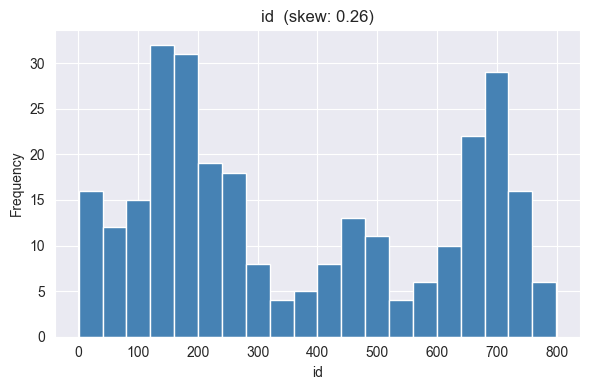

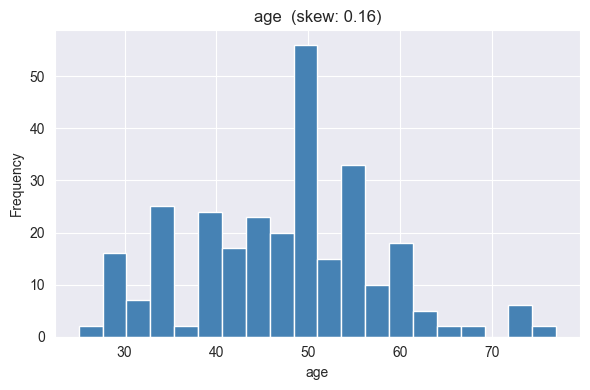

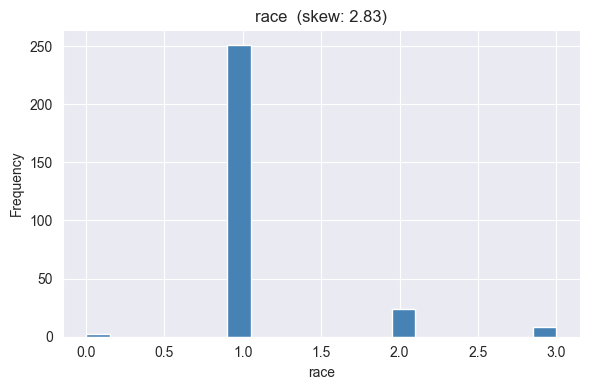

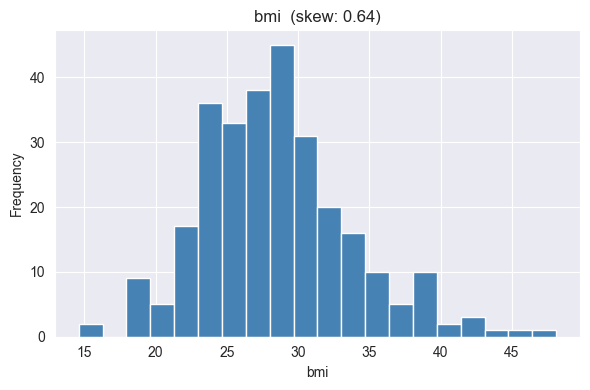

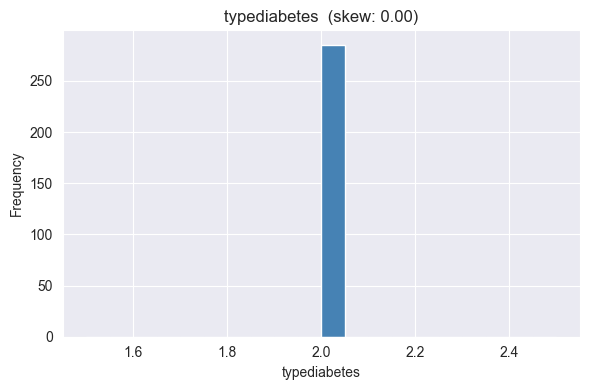

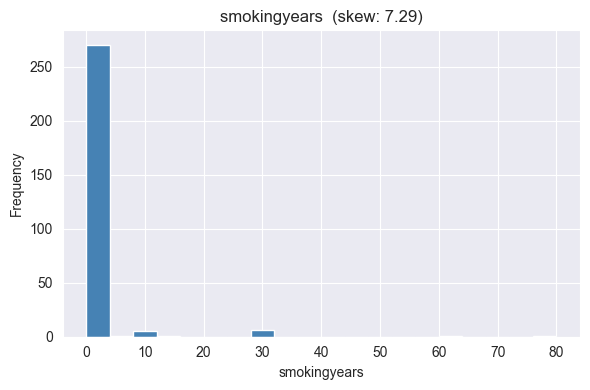

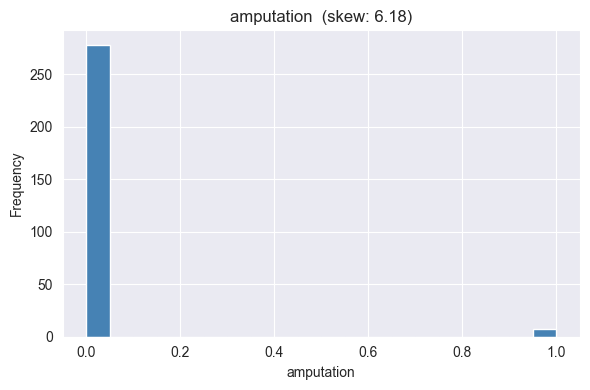

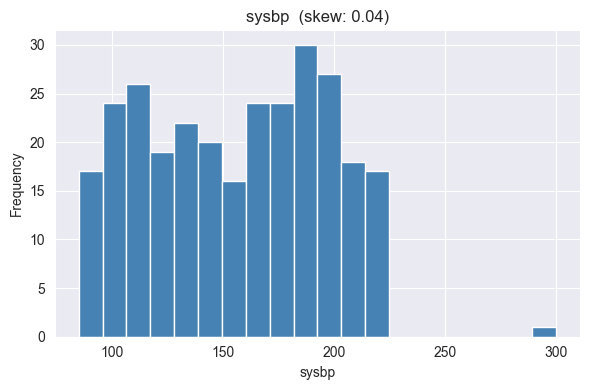

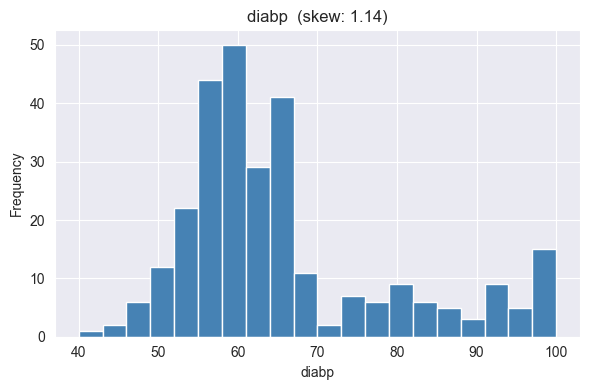

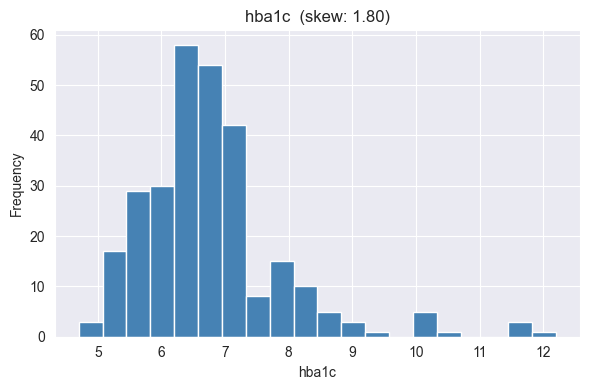

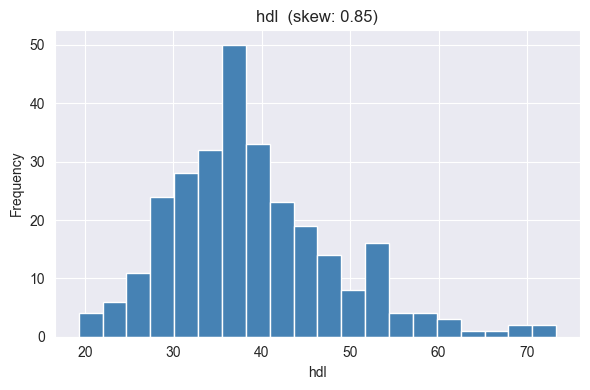

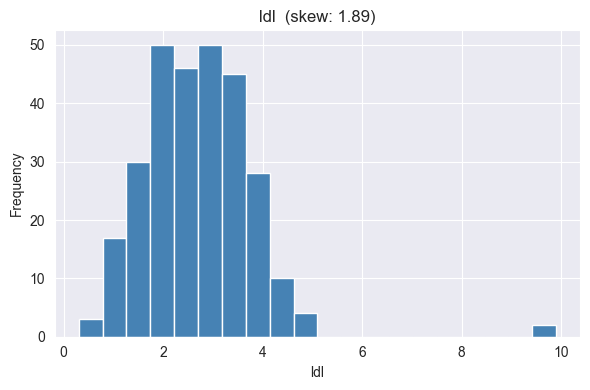

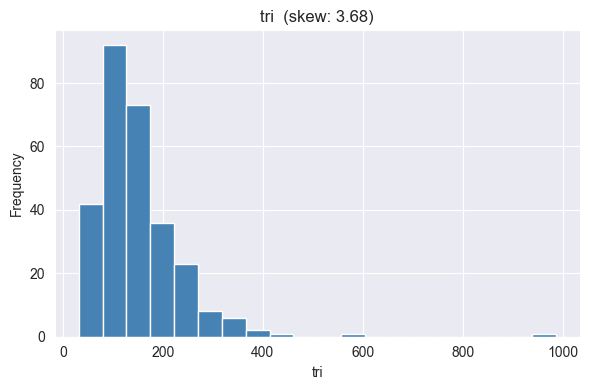

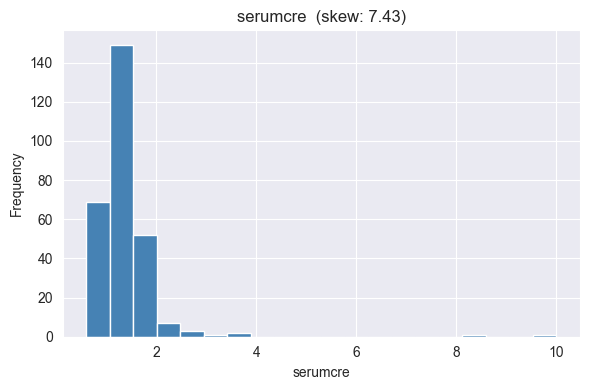

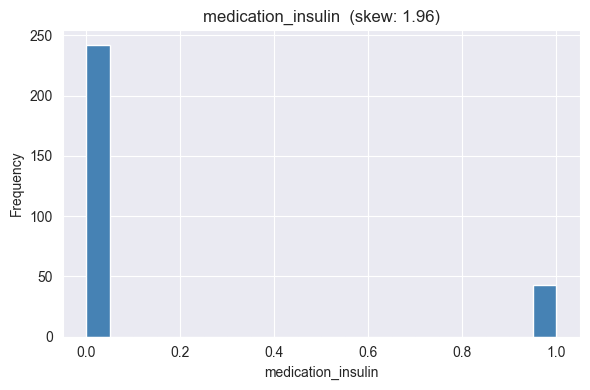

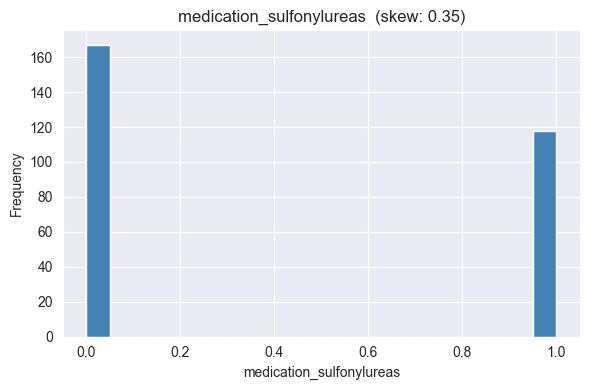

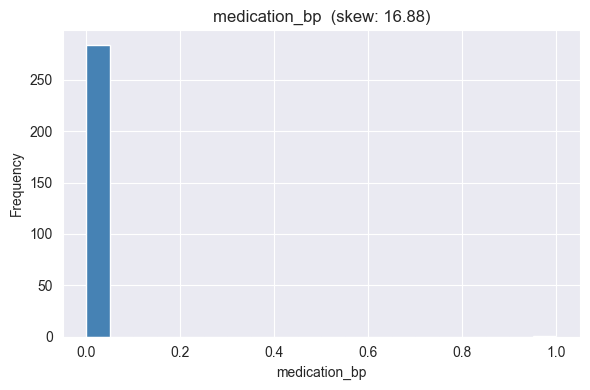

In [25]:

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].dropna().plot(kind='hist', bins=20, color='steelblue', edgecolor='white')
    plt.title(f"{col}  (skew: {df[col].skew():.2f})")
    plt.xlabel(col)
    plt.tight_layout()
    #plt.savefig(f"skew_{col}.png", dpi=150)
    plt.show()

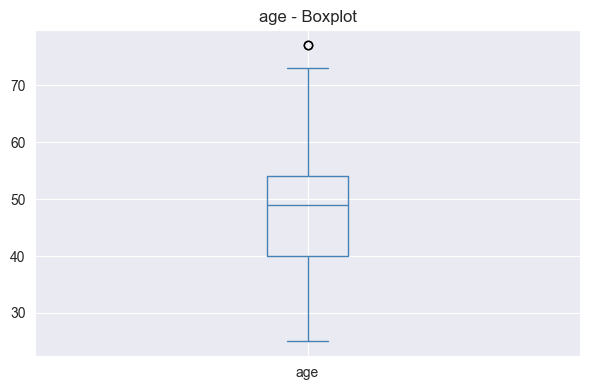

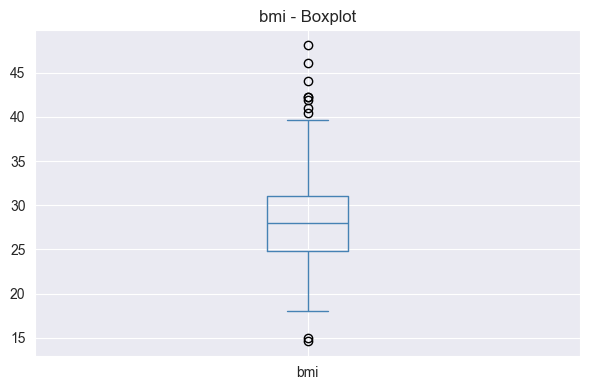

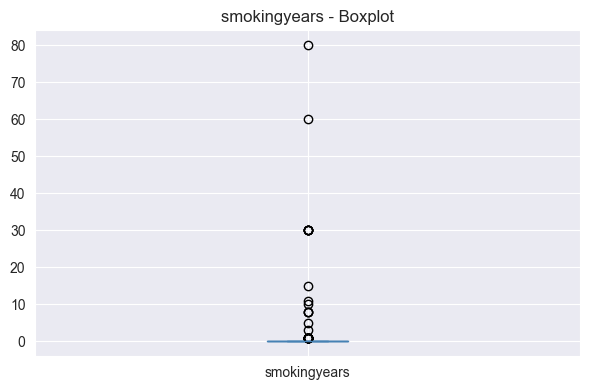

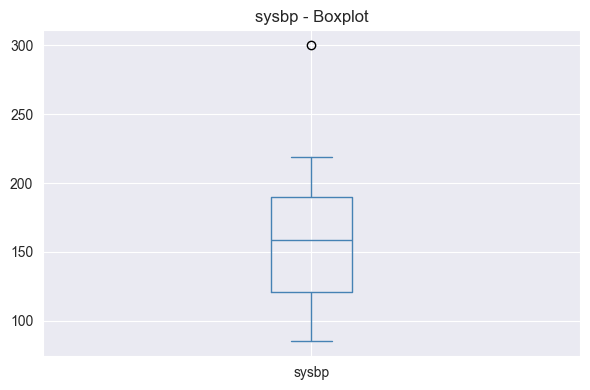

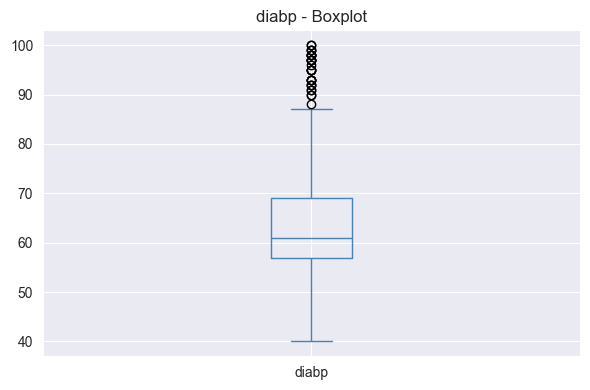

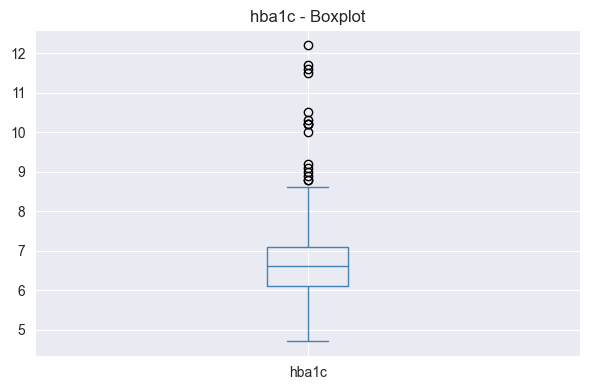

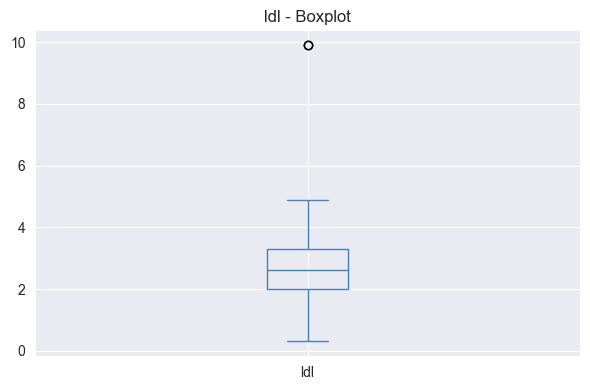

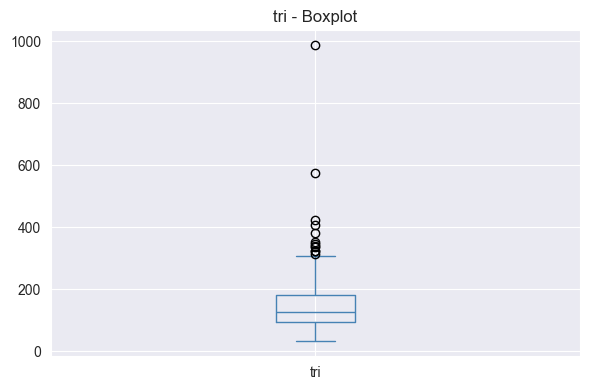

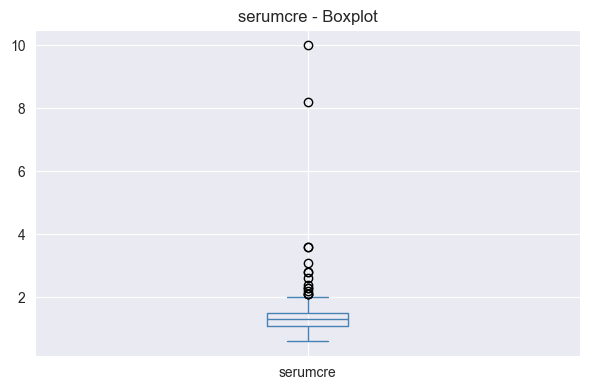

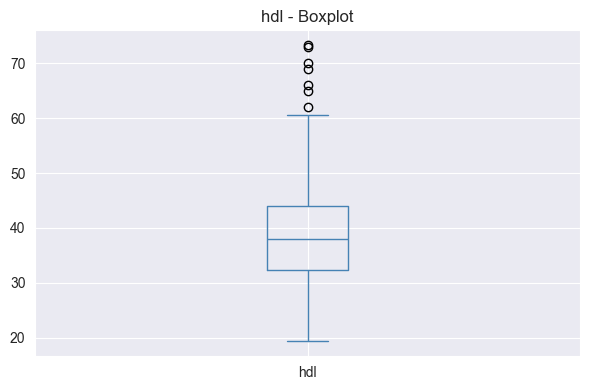

In [26]:

numeric_cols = ["age", "bmi", "smokingyears", "sysbp", "diabp", "hba1c", "ldl", "tri", "serumcre", "hdl"]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].dropna().plot(kind='box', color='steelblue')
    plt.title(f"{col} - Boxplot")
    plt.tight_layout()
    #plt.savefig(f"box_{col}.png", dpi=150)
    plt.show()

In [29]:
print(df[df["sysbp"] > 250])

     id gender  age  race   bmi marital_status  typediabetes  smokingyears  \
49  210      F   47     1  22.2         single             2             0   

    amputation  sysbp  ...   hdl  ldl   tri  serumcre  medication_insulin  \
49           0    300  ...  36.0  2.4  67.0       1.0                   0   

    medication_sulfonylureas  medication_bp  \
49                         0              0   

    diabetic_macrovascular_complications  \
49                                   NaN   

    diabetic_microvascular_complications comorbidities  
49                                   NaN           NaN  

[1 rows x 22 columns]


In [31]:
print(df[df["smokingyears"] >= 80])

     id gender  age  race   bmi marital_status  typediabetes  smokingyears  \
32  650      M   36     1  23.0         single             2            80   

    amputation  sysbp  ...   hdl  ldl   tri  serumcre  medication_insulin  \
32           0    181  ...  45.5  1.9  89.0       0.8                   0   

    medication_sulfonylureas  medication_bp  \
32                         1              0   

                 diabetic_macrovascular_complications  \
32  peripheral arterial disease | cerebrovascular ...   

      diabetic_microvascular_complications  \
32  nephropathy | neuropathy | retinopathy   

                                        comorbidities  
32  hypertension | hypertension | hyperuricemia | ...  

[1 rows x 22 columns]
